Notebook Objective

This notebook focuses on discovering business insights from the prepared datasets.

Unlike Feature Engineering, EDA answers business questions rather than creating new columns.

Notebook Structure
1. Import Libraries

2. Load Final Processed Data

3. Dataset Overview

4. Univariate Analysis

5. Bivariate Analysis

6. Multivariate Analysis

7. Business Insights

8. Summary

In [ ]:
#!pip install matplotlib
#!pip install seaborn

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

Cell 2 – Load Data

In [7]:

fact_orders = pd.read_csv(
    r"C:\Users\Steve\Desktop\datascience-project1\project\data\processed\final_processed_datasets\fact_orders_fe.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

sales_fact = pd.read_csv(
    r"C:\Users\Steve\Desktop\datascience-project1\project\data\processed\final_processed_datasets\sales_fact_fe.csv",
    parse_dates=[
        "shipping_limit_date",
        "order_purchase_timestamp",
    ],
)

finalized Datasets overview 

In [8]:
print("=" * 60)
print("FACT ORDERS")
print("=" * 60)

display(fact_orders.head())

print(f"\nShape : {fact_orders.shape}")

print("\n")

print("=" * 60)
print("SALES FACT")
print("=" * 60)

display(sales_fact.head())

print(f"\nShape : {sales_fact.shape}")

FACT ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_after_carrier_flag,late_delivery_flag,delivery_before_carrier_flag,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,review_score,review_comment_title,review_comment_message,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,approval_time_hours,shipping_time_days,delivery_time_days,total_order_cycle_days,estimated_delivery_days,delivery_delay_days,avg_payment_per_installment,multiple_payment_methods,high_rating,low_rating,is_delivered,is_cancelled,is_in_progress
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,"credit_card, voucher",1.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017,10,October,4,2,Monday,10,0.178333,2.0,6.0,8.0,15,-8.0,38.710000,True,True,False,True,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,1.0,4.0,Muito boa a loja,Muito bom o produto.,2018,7,July,3,24,Tuesday,20,30.713889,0.0,12.0,13.0,19,-6.0,141.460000,False,True,False,True,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,credit_card,3.0,5.0,NaN,NaN,2018,8,August,3,8,Wednesday,8,0.276111,0.0,9.0,9.0,26,-18.0,59.706667,False,True,False,True,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,1.0,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017,11,November,4,18,Saturday,19,0.298056,3.0,9.0,13.0,26,-13.0,72.200000,False,True,False,True,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,credit_card,1.0,5.0,NaN,NaN,2018,2,February,1,13,Tuesday,21,1.030556,0.0,1.0,2.0,12,-10.0,28.620000,False,True,False,True,False,False



Shape : (99441, 42)


SALES FACT


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_purchase_timestamp,order_status,customer_state,customer_city,late_delivery_flag,review_score,total_item_value,freight_percentage,is_heavy_product,product_volume_cm3,is_large_product,high_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277,volta redonda,SP,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,RJ,campos dos goytacazes,False,5.0,72.19,22.563667,False,3528.0,False,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471,sao paulo,SP,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,SP,santa fe do sul,False,4.0,259.83,8.307628,True,60000.0,True,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564,borda da mata,MG,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,MG,para de minas,False,5.0,216.87,8.979899,True,14157.0,True,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,14403,franca,SP,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,SP,atibaia,False,4.0,25.78,98.460354,False,2400.0,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,87900,loanda,PR,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,SP,varzea paulista,False,5.0,218.04,9.074537,True,42000.0,True,False



Shape : (112650, 31)


DATASET INFORMATION

In [9]:
print("=" * 60)
print("FACT ORDERS INFO")
print("=" * 60)

fact_orders.info()

print("\n")

print("=" * 60)
print("SALES FACT INFO")
print("=" * 60)

sales_fact.info()

FACT ORDERS INFO
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   approval_after_carrier_flag    99441 non-null  bool          
 9   late_delivery_flag             99441 non-null  bool          
 10  delivery_before_carrier_flag   99441 non-null  bool          
 11  customer_

Statistical Summary


In [ ]:
display(
    fact_orders.describe(include="all")
)

display(
    sales_fact.describe(include="all")
)

EDA Structure

We'll answer business questions in a logical sequence.

1. Sales Performance
2. Customer Behaviour
3. Product Analysis
4. Delivery Performance
5. Customer Satisfaction
6. Payment Analysis
7. Key Business Insights

This mirrors how a business reviews performance.

### Section 1 — Sales Performance

Business Question 1

How much revenue has the company generated?

Revenue is the sum of all product prices.

Since sales_fact contains one row per order item, it is the correct dataset for revenue calculations.

In [11]:
# TOTAL REVENUE 
total_revenue = sales_fact["price"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 13,591,643.70


Business Question 2

How many unique orders were placed?


In [12]:

total_orders = fact_orders["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 99,441


 
Business Question 3

How many unique customers made purchases?


In [13]:

unique_customers = fact_orders["customer_id"].nunique()

print(f"Unique Customers: {unique_customers:,}")

Unique Customers: 99,441


Business Question 4

Average Order Value (AOV)?

Average Order Value measures how much customers spend per order.

Formula:

AOV= Number of Orders / Total Revenue​


In [14]:
average_order_value = (
    sales_fact["price"].sum()
    / fact_orders["order_id"].nunique()
)

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 136.68


In [15]:
kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Average Order Value"
    ],
    "Value": [
        f"{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{unique_customers:,}",
        f"{average_order_value:.2f}"
    ]
})

display(kpis)

,Metric,Value
0,Total Revenue,"13,591,643.70"
1,Total Orders,"99,441"
2,Unique Customers,"99,441"
3,Average Order Value,136.68


* The company generated £13,591,643.70 in revenue during the observed period.
* A total of 99,441 orders were placed by 99,441 unique customers.
* The average customer spent £136.68 per order, providing a benchmark for future revenue analysis.

### Section 1.2 — Monthly Revenue Trend

This is one of the most important analyses in any sales project.

How has revenue changed over time?

A business manager wants to know:

* Is revenue growing?
* Are there seasonal patterns?
* Which months perform best?
* Are there periods of decline?

#### Create a Month Column

In [17]:
sales_fact["purchase_month"] = (
    sales_fact["order_purchase_timestamp"]
    .dt.to_period("M")
)

### monthly revenue

In [18]:
monthly_revenue = (
    sales_fact
    .groupby("purchase_month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue["purchase_month"] = (
    monthly_revenue["purchase_month"]
    .astype(str)
)

monthly_revenue.head()

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


#### plot the monthly trend

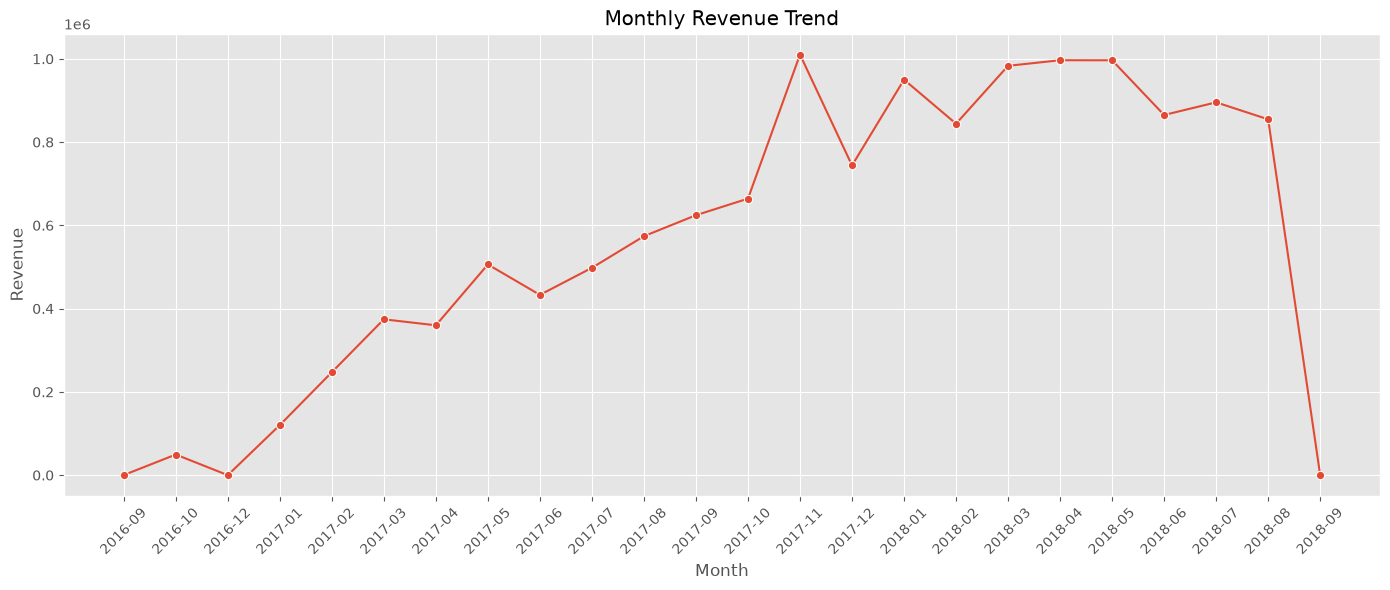

In [19]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="price",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
highest_month = monthly_revenue.loc[ monthly_revenue["price"].idxmax()]

lowest_month = monthly_revenue.loc[ monthly_revenue["price"].idxmin()]

print("Highest Revenue Month")
display(highest_month)

print("\nLowest Revenue Month")
display(lowest_month)

Highest Revenue Month


purchase_month       2017-11
price             1010271.37
Name: 13, dtype: object


Lowest Revenue Month


purchase_month    2016-12
price                10.9
Name: 2, dtype: object